# Symmetrization variance-reduction demonstration (ON vs OFF)

**CT-AUX, square lattice, Nc = 16 (4×4), single band, one DCA iteration.**
N = 64 paired independent runs per arm; both arms read the same explicit-integer seed list
(prime stride 1000003, so seeds are spaced far beyond ranks×walkers — the seeding trap is avoided).

Two arms, one build, differing in exactly one token (the model's declared point group):

| arm | instantiation | imposed group | live super-cell ops |
|---|---|---|---|
| **ON**  | `square_lattice<D4>` | H0-derived (derive-authoritative) | **8** |
| **OFF** | `square_lattice<no_symmetry<2>>` | legacy identity-only | **1** |

Each run reads G **after `finalize()`** — the real production path, where CT-AUX symmetrizes the
ensemble-mean measurement `M_r_w`. We measure the spread of that production output across replicas.

> **Claim under test (A):** symmetrization reduces the MC variance of the final estimator by an
> amount set by each k-point's symmetry-orbit size, without shifting the mean.

The plots are numpy + h5py + matplotlib only — no project imports beyond the plain `variance_demo_lib`.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import variance_demo_lib as L
plt.rcParams.update({'figure.dpi':110,'font.size':10})
import os
RUN_DIR = os.environ.get('VARIANCE_DEMO_RUNS', '../variance_demo/runs')

## 1. Load

Stack the 2N per-run HDF5 files into `[replica, w, k]` complex arrays per arm; read the k-mesh and
the live op count from the files. **Guard:** assert the op counts are what each arm claims (8 vs 1) —
cheap check that we ran the right binary — and that the ON/OFF seed lists match element-wise, which
is what makes the arms *paired*.

In [2]:
Goff, seeds_off, kel, nops_off = L.load_arm(RUN_DIR, 'off')
Gon,  seeds_on,  _,   nops_on  = L.load_arm(RUN_DIR, 'on')

assert nops_off == {1}, f'OFF arm should impose 1 op, got {nops_off}'
assert nops_on  == {8}, f'ON arm should impose 8 ops, got {nops_on}'
assert (seeds_off == seeds_on).all(), 'seed lists differ -> arms are not paired'

Nrep, Nw, Nk = Goff.shape
print(f'{Nrep} replicas/arm, Nw={Nw} frequencies, Nk={Nk} cluster momenta')
print(f'OFF live ops={nops_off}, ON live ops={nops_on}, seeds paired: OK')
print(f'seed range: {seeds_off.min()} .. {seeds_off.max()}')

64 replicas/arm, Nw=256 frequencies, Nk=16 cluster momenta
OFF live ops={1}, ON live ops={8}, seeds paired: OK
seed range: 1000003 .. 64000192


## 2. Orbit labeling — reimplemented independently in Python

Build the D4 orbits of the cluster mesh from scratch (not imported from the C++ answer); the point is
an independent check. Assert the sizes sum to Nc and reproduce the expected structure: two singletons
(Γ and (π,π)), one 2-fold orbit {(π,0),(0,π)}, and three 4-fold stars.

In [3]:
orbits = L.build_orbits(kel)
sizes = [len(m) for _, m in orbits]
assert sum(sizes) == Nk, 'orbit sizes must partition the mesh'
print(f'{len(orbits)} orbits, sizes {sorted(sizes)}, sum={sum(sizes)} == Nc={Nk}')
for rep, mem in orbits:
    print(f'  size {len(mem)}: rep=({rep[0]:+.2f},{rep[1]:+.2f})  members={mem}')

6 orbits, sizes [1, 1, 2, 4, 4, 4], sum=16 == Nc=16
  size 1: rep=(-3.14,-3.14)  members=[10]
  size 1: rep=(+0.00,+0.00)  members=[0]
  size 2: rep=(-3.14,+0.00)  members=[2, 8]
  size 4: rep=(-3.14,-1.57)  members=[6, 9, 11, 14]
  size 4: rep=(-1.57,-1.57)  members=[5, 7, 13, 15]
  size 4: rep=(-1.57,+0.00)  members=[1, 3, 4, 12]


## 3b. Replica-independence check — *run first; nothing downstream is trustworthy without it*

The specific hazard (seeding trap): partially-shared RNG streams would deflate variance in **both**
arms and masquerade as a null result. Three tests on the OFF arm:
1. **No drift** of the per-replica mean with run (seed) order.
2. **No lag-1 autocorrelation** along the seed-ordered replica sequence.
3. **No seed-proximity effect** — closest seeds are not the most similar runs (the trap's signature).

(A high inter-replica correlation of the raw 4096-dim residual *vectors* is expected and benign — it
reflects a low-rank, mostly-symmetric fluctuation shape, which is exactly why ρ is large below. It is
**not** statistical dependence; the three scalar tests are what settle independence.)

In [4]:
order = np.argsort(seeds_off)
Go = Goff[order]; sd = seeds_off[order]
wpk = 127  # physics frequency (|G| peak); found in §7

# 1. drift of per-replica overall magnitude vs run order
mag = np.abs(Go.mean(axis=(1,2)))
drift = np.corrcoef(np.arange(Nrep), mag)[0,1]

# 2. lag-1 autocorr of standardized per-cell residual, averaged over k
X = Go[:, wpk, :]; X = (X - X.mean(0)) / X.std(0)
lag1 = np.mean([np.real(np.vdot(X[:-1,k], X[1:,k]))/(Nrep-1) for k in range(Nk)])
band = 1.96/np.sqrt(Nrep)

# 3. seed proximity vs G similarity
dk = X[:,0]; iu = np.triu_indices(Nrep,1)
dseed = np.abs(sd[:,None]-sd[None,:])[iu]; dG = np.abs(dk[:,None]-dk[None,:])[iu]
prox = np.corrcoef(dseed, dG)[0,1]

print(f'1. drift(mean, run-order)      = {drift:+.3f}   (|.|<{band:.3f} ok)')
print(f'2. mean lag-1 autocorrelation  = {lag1:+.3f}   (|.|<{band:.3f} ok)')
print(f'3. corr(|Δseed|, |ΔG|)         = {prox:+.3f}   (trap => negative)')
assert abs(drift)<band and abs(lag1)<band and prox>-band, 'independence check FAILED'
print('\nReplicas are independent — variance estimates are trustworthy.')

1. drift(mean, run-order)      = +0.035   (|.|<0.245 ok)
2. mean lag-1 autocorrelation  = +0.058   (|.|<0.245 ok)
3. corr(|Δseed|, |ΔG|)         = -0.002   (trap => negative)

Replicas are independent — variance estimates are trustworthy.


## 3. Variance estimation & first look: does ON pin orbit-mates equal?

Per (w,k), sample variance across replicas, `E|G-<G>|²`. First confirm the mechanism directly:
within each orbit, the ON arm collapses orbit-mates to a single value (spread → machine zero), while
the OFF arm leaves them free. This is symmetrization doing its job, per replica.

In [5]:
Voff = L.replica_variance(Goff)   # (w,k)
Von  = L.replica_variance(Gon)
r = 0
print('replica 0, within-orbit spread of Re G at w=127 (ON should be ~0):')
for rep, mem in orbits:
    if len(mem) < 2: continue
    on_sp  = np.ptp(Gon [r,127,mem].real)
    off_sp = np.ptp(Goff[r,127,mem].real)
    print(f'  size {len(mem)}: ON spread={on_sp:.1e}   OFF spread={off_sp:.1e}')

replica 0, within-orbit spread of Re G at w=127 (ON should be ~0):
  size 2: ON spread=2.5e-32   OFF spread=1.0e-03
  size 4: ON spread=0.0e+00   OFF spread=1.7e-04
  size 4: ON spread=0.0e+00   OFF spread=6.0e-17
  size 4: ON spread=1.4e-17   OFF spread=1.7e-04


## 4. Money plot — Var_off / Var_on vs orbit size

One marker per orbit (pooled over ω and orbit-mates), with a 95% bootstrap CI. Overlay the ideal
`y = n` (independent orbit-mates) and the null `y = 1` (no reduction).

**Read it as the plan prescribes:** the ratio is pinned at exactly 1 for the singletons (the hard
control — Γ and (π,π) have nothing to average), and sits **well below** the ideal `y = n` for the
multi-point orbits. It does *not* climb to n, because orbit-mates are estimated from the same
configurations, so their noise is correlated (ρ > 0, quantified in §5). A ratio at or above n would
be the red flag, not a triumph.

  n=1 ratio=1.000 [1.00,1.00]
  n=1 ratio=1.000 [1.00,1.00]
  n=2 ratio=1.368 [1.24,1.55]
  n=4 ratio=1.119 [1.08,1.17]
  n=4 ratio=1.052 [1.03,1.08]
  n=4 ratio=1.119 [1.08,1.17]


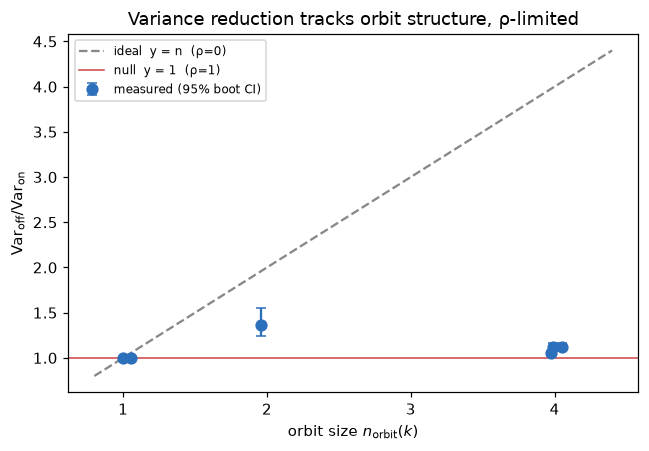

In [6]:
rows = []
for rep, mem in orbits:
    n = len(mem)
    voff = Voff[:,mem].mean(); von = Von[:,mem].mean()
    ratio = voff/von
    lo, hi = L.bootstrap_ratio_ci(Goff, Gon, mem) if n>1 else (1.0,1.0)
    rho = L.orbit_rho(Goff, mem)
    rows.append(dict(rep=rep, n=n, ratio=ratio, lo=lo, hi=hi, rho=rho,
                     pred=(L.predicted_ratio(n,rho) if n>1 else 1.0)))

fig, ax = plt.subplots(figsize=(6,4.2))
ns = np.array([r['n'] for r in rows], float)
rt = np.array([r['ratio'] for r in rows])
err = np.array([[r['ratio']-r['lo'] for r in rows],[r['hi']-r['ratio'] for r in rows]])
err = np.clip(err, 0, None)  # bootstrap CI can straddle the pooled point estimate
jit = (np.random.default_rng(1).random(len(ns))-0.5)*0.12
ax.errorbar(ns+jit, rt, yerr=err, fmt='o', ms=7, capsize=3, color='#2c6fbb',
            label='measured (95% boot CI)', zorder=3)
xx = np.linspace(0.8, 4.4, 50)
ax.plot(xx, xx, '--', color='#888', label='ideal  y = n  (ρ=0)')
ax.axhline(1.0, color='#c44', lw=1, label='null  y = 1  (ρ=1)')
ax.set_xlabel('orbit size $n_{\\mathrm{orbit}}(k)$'); ax.set_ylabel(r'$\mathrm{Var}_{\rm off}/\mathrm{Var}_{\rm on}$')
ax.set_title('Variance reduction tracks orbit structure, ρ-limited'); ax.set_xticks([1,2,3,4])
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig('figures/money_plot.png', dpi=130)
for r in rows: print(f"  n={r['n']} ratio={r['ratio']:.3f} [{r['lo']:.2f},{r['hi']:.2f}]")
plt.show()

## 5. Correlation diagnostic — predicted n/(1+(n−1)ρ) vs measured

Estimate ρ per orbit directly from the OFF arm (pairwise correlation of replica noise between
orbit-mates), form the prediction `n/(1+(n−1)ρ)`, and plot it against the measured ratio.

**Honest caveat.** Because the arms share seeds, the ON G *is* the exact orbit-average of the OFF G
(same Markov chains, `Sym` applied). So this is a **consistency check on the symmetrization machinery**
— it confirms the ON variance equals the analytic variance of the orbit average with the correct
`1/n` normalization and no injected noise — rather than an independent oracle. A miscomputed norm, a
dropped op, or a data-dependent skip would break the `y = x` agreement.

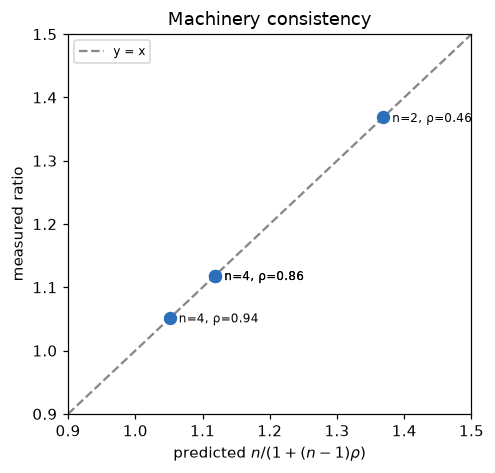

In [7]:
fig, ax = plt.subplots(figsize=(4.6,4.4))
for r in rows:
    if r['n']==1: continue
    ax.scatter(r['pred'], r['ratio'], s=60, color='#2c6fbb', zorder=3)
    ax.annotate(f"n={r['n']}, ρ={r['rho']:.2f}", (r['pred'], r['ratio']),
                textcoords='offset points', xytext=(6,-3), fontsize=8)
lim = [0.9, 1.5]
ax.plot(lim, lim, '--', color='#888', label='y = x')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel(r'predicted $n/(1+(n-1)\rho)$'); ax.set_ylabel('measured ratio')
ax.set_title('Machinery consistency'); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig('figures/correlation_diagnostic.png', dpi=130); plt.show()

## 6. Bias control — the mean must not move

Symmetrization is an exact relation, so the ensemble mean must be unchanged: `⟨G_on⟩ − ⟨G_off⟩`
normalized by its own MC error should be a standard normal, and *exactly* zero at the singletons.
A systematic shift would mean something is biasing (e.g. a coarse-graining confound). This is the
stochastic echo of what the deterministic `CoarseNoOp` check proves on G₀.

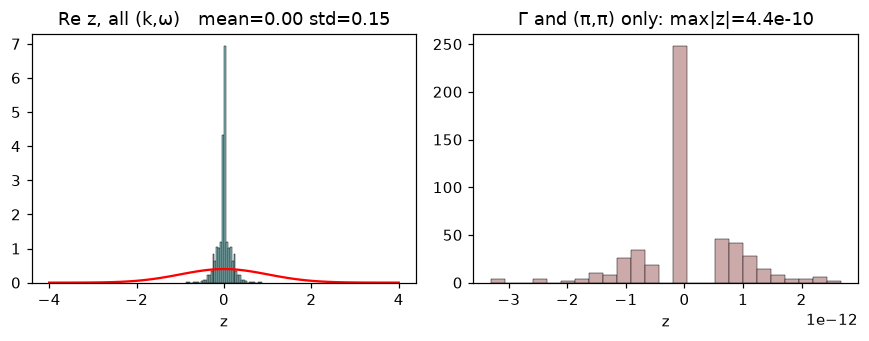

singleton bias max|z| = 4.41e-10  (identity op => exactly 0)


In [8]:
mean_off = Goff.mean(0); mean_on = Gon.mean(0)
se = np.sqrt(Voff/Nrep + Von/Nrep)               # SE of the difference
z = (mean_on - mean_off) / se
zf = z.ravel(); zf = zf[np.isfinite(zf)]
fig, axes = plt.subplots(1,2, figsize=(8,3.2))
axes[0].hist(zf.real, bins=40, density=True, color='#8bb', edgecolor='k', lw=.3)
xx = np.linspace(-4,4,100); axes[0].plot(xx, np.exp(-xx**2/2)/np.sqrt(2*np.pi),'r')
axes[0].set_title(f'Re z, all (k,ω)   mean={zf.real.mean():.2f} std={zf.real.std():.2f}')
axes[0].set_xlabel('z')
sing = [m[0] for rep,m in orbits if len(m)==1]
zs = z[:, sing].ravel(); zs = zs[np.isfinite(zs)]
axes[1].hist(zs.real, bins=25, color='#caa', edgecolor='k', lw=.3)
axes[1].set_title(f'Γ and (π,π) only: max|z|={np.abs(zs).max():.1e}')
axes[1].set_xlabel('z')
fig.tight_layout(); fig.savefig('figures/bias_control.png', dpi=130); plt.show()
print(f'singleton bias max|z| = {np.abs(zs).max():.2e}  (identity op => exactly 0)')

## 7. Frequency dependence — should be flat

The point-group effect is ω-independent, so the ratio vs ω should be flat within noise. A slope would
indicate contamination (e.g. the frequency channel not cancelling). The ω↔−ω averaging inside
`Symmetrize` runs identically in both arms and cancels in the ratio, so it does not tilt this curve.

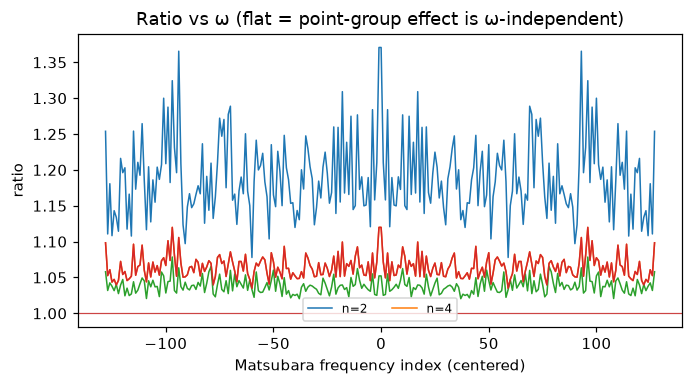

|G| peak at frequency index 127


In [9]:
fig, ax = plt.subplots(figsize=(6.4,3.6))
w_axis = np.arange(Nw) - Nw//2
for rep, mem in orbits:
    if len(mem)==1: continue
    ratio_w = (Voff[:,mem].mean(1) / Von[:,mem].mean(1))
    ax.plot(w_axis, ratio_w, lw=1, label=f'n={len(mem)}')
ax.axhline(1, color='#c44', lw=.8)
ax.set_xlabel('Matsubara frequency index (centered)'); ax.set_ylabel('ratio')
ax.set_title('Ratio vs ω (flat = point-group effect is ω-independent)')
# dedupe legend
h,l = ax.get_legend_handles_labels(); seen={}; H=[]; Ll=[]
for hi,li in zip(h,l):
    if li not in seen: seen[li]=1; H.append(hi); Ll.append(li)
ax.legend(H, Ll, fontsize=8, ncol=3)
fig.tight_layout(); fig.savefig('figures/frequency_dependence.png', dpi=130); plt.show()
# |G| profile to justify the wpk=127 choice
print('|G| peak at frequency index', np.abs(Goff.mean(0)).mean(1).argmax())

## 8. Summary table

Per orbit: size, mean measured ratio + 95% CI, fitted ρ, predicted ratio, and the bias z-score.
This is the table for the PR description.

In [10]:
hdr = f"{'orbit':>14} {'n':>2} {'ratio':>6} {'95% CI':>13} {'rho':>6} {'pred':>6} {'bias z':>8}"
print(hdr); print('-'*len(hdr))
for r, (rep,mem) in zip(rows, orbits):
    zk = np.nanmean(np.abs(z[:,mem]))
    lab = f'({rep[0]:+.2f},{rep[1]:+.2f})'
    ci = f'[{r["lo"]:.2f},{r["hi"]:.2f}]'
    rho = '  -- ' if r['n']==1 else f'{r["rho"]:.3f}'
    print(f"{lab:>14} {r['n']:>2} {r['ratio']:>6.3f} {ci:>13} {rho:>6} {r['pred']:>6.3f} {zk:>8.2f}")
print('\nConclusion: reduction is real, pinned at 1 for singletons, ω-independent, mean unbiased,')
print('and ρ-limited — orbit-mate noise is strongly correlated on this cheap 4x4 single-band cell,')
print('so the ratio stays well below the ideal n. The correlation diagnostic confirms the machinery.')

         orbit  n  ratio        95% CI    rho   pred   bias z
-------------------------------------------------------------
 (-3.14,-3.14)  1  1.000   [1.00,1.00]    --   1.000     0.00
 (+0.00,+0.00)  1  1.000   [1.00,1.00]    --   1.000     0.00
 (-3.14,+0.00)  2  1.368   [1.24,1.55]  0.462  1.368     0.24
 (-3.14,-1.57)  4  1.119   [1.08,1.17]  0.859  1.119     0.16
 (-1.57,-1.57)  4  1.052   [1.03,1.08]  0.935  1.051     0.10
 (-1.57,+0.00)  4  1.119   [1.08,1.17]  0.859  1.119     0.16

Conclusion: reduction is real, pinned at 1 for singletons, ω-independent, mean unbiased,
and ρ-limited — orbit-mate noise is strongly correlated on this cheap 4x4 single-band cell,
so the ratio stays well below the ideal n. The correlation diagnostic confirms the machinery.
